<a href="https://colab.research.google.com/github/Prasanth1782/Arithmetic_calculator/blob/main/Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd

tcs = yf.download(
    "TCS.NS",
    start="2014-01-01",
    end=None,       # till today
    interval="1d"   # daily data
)

/tmp/ipython-input-1948422523.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tcs = yf.download(
[*********************100%***********************]  1 of 1 completed


In [ ]:
tcs.head()

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2014-01-01,825.899292,837.866049,825.055500,836.178464,529952
2014-01-02,831.153748,839.591857,826.992188,830.770197,1726948
2014-01-03,852.325500,854.972054,823.578423,830.271357,2618174
2014-01-06,858.999451,860.687035,842.660167,854.933779,2311810
2014-01-07,846.169678,865.462282,843.427330,859.152896,2897486


In [ ]:
tcs.shape

(2962, 5)

In [ ]:
tcs.columns

MultiIndex([( 'Close', 'TCS.NS'),
            (  'High', 'TCS.NS'),
            (   'Low', 'TCS.NS'),
            (  'Open', 'TCS.NS'),
            ('Volume', 'TCS.NS')],
           names=['Price', 'Ticker'])

In [ ]:
tcs.columns = tcs.columns.get_level_values(0)
tcs.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [ ]:
tcs.isnull().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
tcs.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2962 entries, 2014-01-01 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2962 non-null   float64
 1   High    2962 non-null   float64
 2   Low     2962 non-null   float64
 3   Open    2962 non-null   float64
 4   Volume  2962 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 138.8 KB


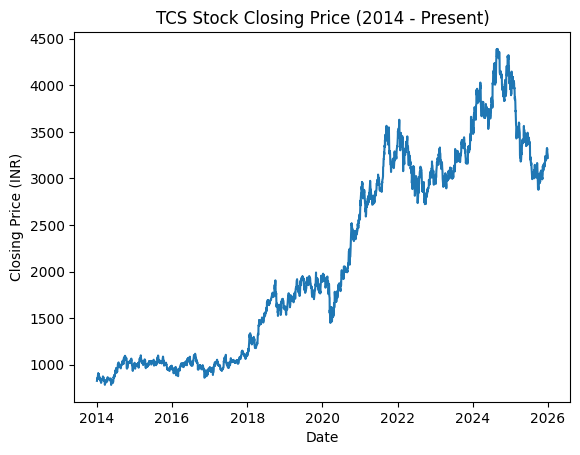

In [ ]:
import matplotlib.pyplot as plt

# Plot Closing Price over time
plt.figure()
plt.plot(tcs.index, tcs['Close'])
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.title("TCS Stock Closing Price (2014 - Present)")
plt.show()


In [ ]:
#Calculating 14-Day Moving Average
tcs['MA_14'] = tcs['Close'].rolling(window=14).mean()
tcs[['Close', 'MA_14']].head(20)

Price,Close,MA_14
Date,,
2014-01-01,825.899292,NaN
2014-01-02,831.153748,NaN
2014-01-03,852.325500,NaN
2014-01-06,858.999451,NaN
2014-01-07,846.169678,NaN
2014-01-08,856.333862,NaN
2014-01-09,859.900757,NaN
2014-01-10,874.839966,NaN
2014-01-13,908.534668,NaN


In [ ]:
#Calculating 14-Day Relative Strength Index

delta = tcs['Close'].diff()

gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

tcs['RSI_14'] = 100 - (100 / (1 + rs))

tcs[['Close', 'RSI_14']].head(20)

Price,Close,RSI_14
Date,,
2014-01-01,825.899292,NaN
2014-01-02,831.153748,NaN
2014-01-03,852.325500,NaN
2014-01-06,858.999451,NaN
2014-01-07,846.169678,NaN
2014-01-08,856.333862,NaN
2014-01-09,859.900757,NaN
2014-01-10,874.839966,NaN
2014-01-13,908.534668,NaN


In [ ]:
tcs.isnull().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0
MA_14,13
RSI_14,13


In [ ]:
tcs_clean = tcs.dropna()

print("Before cleaning:", tcs.shape)
print("After cleaning:", tcs_clean.shape)

Before cleaning: (2962, 7)
After cleaning: (2949, 7)


In [ ]:
#Verifying Final Dataset
tcs_clean.head()

Price,Close,High,Low,Open,Volume,MA_14,RSI_14
Date,,,,,,,
2014-01-20,896.817749,901.343664,849.756122,851.079352,6010558,868.314266,64.986308
2014-01-21,874.609985,897.220262,872.615542,895.206623,3132282,871.793601,59.410199
2014-01-22,872.212769,880.957736,868.396461,877.218120,2384030,874.726388,58.020550
2014-01-23,863.928101,873.229198,858.117349,869.930721,2290762,875.555145,52.386637
2014-01-24,862.489990,875.741679,857.235367,860.687322,1850266,875.804470,50.733805


In [ ]:
#Verifying Final Dataset
tcs_clean.tail()

Price,Close,High,Low,Open,Volume,MA_14,RSI_14
Date,,,,,,,
2025-12-25,3319.000000,3319.0,3319.000000,3319.000000,0,3252.514282,65.610546
2025-12-26,3280.000000,3320.0,3271.800049,3313.100098,1176664,3255.621425,57.345501
2025-12-29,3251.500000,3288.0,3242.899902,3280.000000,2079473,3258.707136,57.287450
2025-12-30,3246.800049,3267.5,3239.500000,3250.000000,2807593,3262.821429,60.212801
2025-12-31,3220.899902,3246.0,3211.500000,3240.000000,604452,3264.892857,54.750988


In [ ]:
# Creating next-day target variable

tcs_forecast = tcs_clean.copy()

# Shift Close price to represent next-day Close
tcs_forecast['Close_next_day'] = tcs_forecast['Close'].shift(-1)

tcs_forecast = tcs_forecast.dropna()

print("Forecast dataset shape:", tcs_forecast.shape)
tcs_forecast.head()

Forecast dataset shape: (2948, 8)


Price,Close,High,Low,Open,Volume,MA_14,RSI_14,Close_next_day
Date,,,,,,,,
2014-01-20,896.817749,901.343664,849.756122,851.079352,6010558,868.314266,64.986308,874.609985
2014-01-21,874.609985,897.220262,872.615542,895.206623,3132282,871.793601,59.410199,872.212769
2014-01-22,872.212769,880.957736,868.396461,877.218120,2384030,874.726388,58.020550,863.928101
2014-01-23,863.928101,873.229198,858.117349,869.930721,2290762,875.555145,52.386637,862.489990
2014-01-24,862.489990,875.741679,857.235367,860.687322,1850266,875.804470,50.733805,856.687866


In [ ]:
# Defining features and next-day target

feature_columns = ['Open', 'High', 'Low', 'Volume', 'MA_14', 'RSI_14']

X = tcs_forecast[feature_columns]
y = tcs_forecast['Close_next_day']

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head(), y.head()

X shape: (2948, 6)
y shape: (2948,)


(Price             Open        High         Low   Volume       MA_14     RSI_14
 Date                                                                          
 2014-01-20  851.079352  901.343664  849.756122  6010558  868.314266  64.986308
 2014-01-21  895.206623  897.220262  872.615542  3132282  871.793601  59.410199
 2014-01-22  877.218120  880.957736  868.396461  2384030  874.726388  58.020550
 2014-01-23  869.930721  873.229198  858.117349  2290762  875.555145  52.386637
 2014-01-24  860.687322  875.741679  857.235367  1850266  875.804470  50.733805,
 Date
 2014-01-20    874.609985
 2014-01-21    872.212769
 2014-01-22    863.928101
 2014-01-23    862.489990
 2014-01-24    856.687866
 Name: Close_next_day, dtype: float64)

In [ ]:
# Time-based Train-Test Split (80% / 20%)

train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print("Training samples:", X_train.shape, y_train.shape)
print("Testing samples :", X_test.shape, y_test.shape)

Training samples: (2358, 6) (2358,)
Testing samples : (590, 6) (590,)


In [ ]:
# Train Linear Regression (Next-Day Forecasting)

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict next-day closing prices
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression model trained (next-day forecasting).")

Linear Regression model trained (next-day forecasting).


In [ ]:
# Evaluation Metrics for Linear Regression (Next-Day Forecast)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression (Next-Day Forecasting) Performance:")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

Linear Regression (Next-Day Forecasting) Performance:
MAE  : 35.19579360387669
RMSE : 48.53544111869049
R²   : 0.9844722676264269


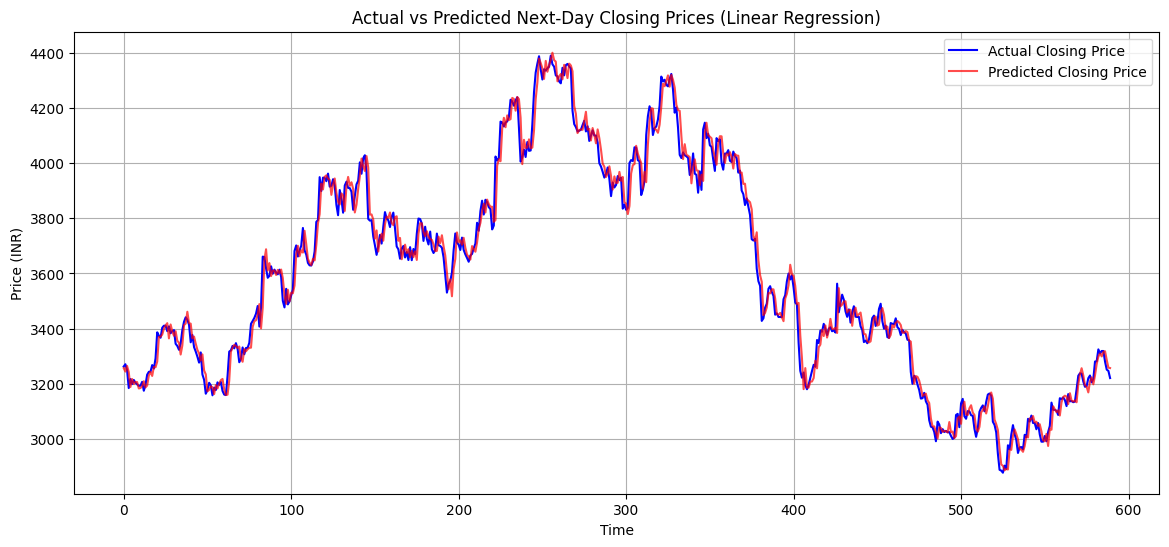

In [ ]:
# Plot Actual vs Predicted Closing Prices

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label="Actual Closing Price", color="blue")
plt.plot(y_pred_lr, label="Predicted Closing Price", color="red", alpha=0.7)

plt.title("Actual vs Predicted Next-Day Closing Prices (Linear Regression)")
plt.xlabel("Time")
plt.ylabel("Price (INR)")
plt.legend()
plt.grid(True)

plt.show()


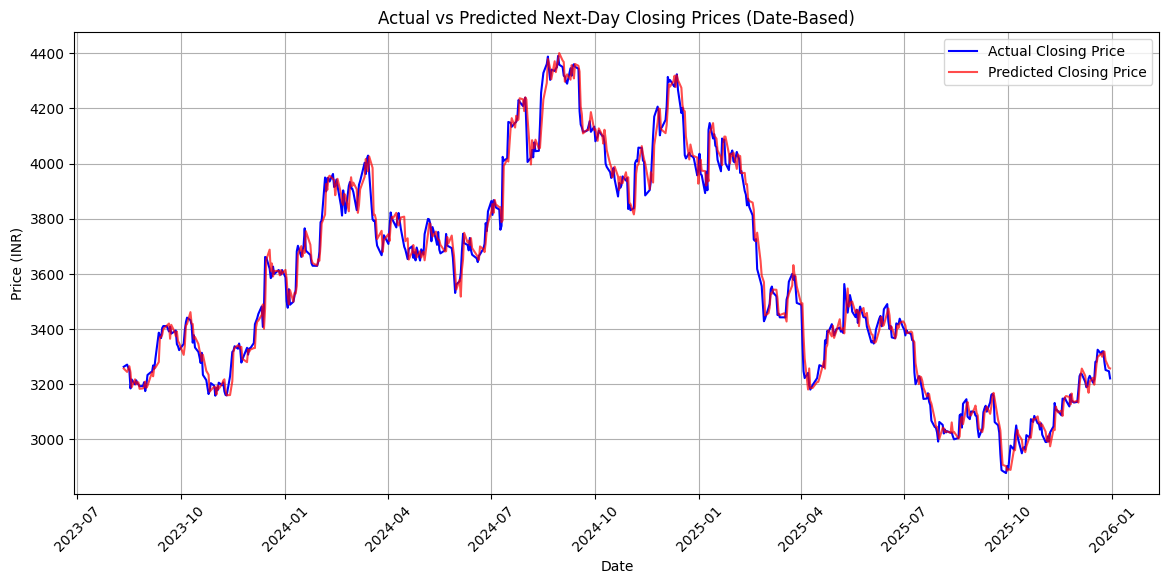

In [ ]:
# Date-based Actual vs Predicted Plot

# Getting dates corresponding to test set
test_dates = tcs_forecast.index[train_size:]

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual Closing Price",
    color="blue"
)

plt.plot(
    test_dates,
    y_pred_lr,
    label="Predicted Closing Price",
    color="red",
    alpha=0.7
)

plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.title("Actual vs Predicted Next-Day Closing Prices (Date-Based)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()
